<a href="https://colab.research.google.com/github/bahmedx/733/blob/main/Hands_On_Project_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Setup and Data Loading**

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn modules
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

# Load the Adult Census Income dataset (Predicting Income >50K)
# This dataset is excellent for both classification and ethical bias evaluation
print("Fetching dataset...")
data = fetch_openml(data_id=1590, as_frame=True, parser='auto')
df = data.frame

# Display basic info
display(df.head())
print(f"Dataset shape: {df.shape}")

Fetching dataset...


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


Dataset shape: (48842, 15)


In [8]:
print("Class Distribution:")
print(y.value_counts())
print("\nClass Distribution (%):")
print((y.value_counts(normalize=True) * 100).round(2))

Class Distribution:
class
0    37155
1    11687
Name: count, dtype: int64

Class Distribution (%):
class
0    76.07
1    23.93
Name: proportion, dtype: float64


**Data Preprocessing & Splitting**

In [2]:
# Define features (X) and target (y)
# Target is 'class' (>50K or <=50K)
X = df.drop('class', axis=1)
y = df['class'].apply(lambda x: 1 if x == '>50K' else 0) # Encode target as binary

# Identify numerical and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

# Create preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Split the data (75/25 split, stratified due to class imbalance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 36631
Test set size: 12211


**Baseline Model Development**

In [3]:
# Establish a baseline using DummyClassifier (predicts the majority class)
baseline_clf = DummyClassifier(strategy='prior')
baseline_clf.fit(X_train, y_train)

baseline_acc = baseline_clf.score(X_test, y_test)
print(f"Baseline Accuracy (predicting majority class): {baseline_acc:.4f}")

Baseline Accuracy (predicting majority class): 0.7607


**Model 1 - Logistic Regression (with Cross-Validation)**

In [4]:
# Build a pipeline for Logistic Regression
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# Perform 5-fold cross-validation
cv_scores = cross_val_score(log_reg_pipeline, X_train, y_train, cv=5, scoring='accuracy')
print(f"LogReg CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Fit the model and evaluate on test set
log_reg_pipeline.fit(X_train, y_train)
y_pred_log = log_reg_pipeline.predict(X_test)

LogReg CV Accuracy: 0.8061 (+/- 0.0054)


**Model 2 - Random Forest (with Hyperparameter Tuning)**

In [5]:
# Build a pipeline for Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Define parameter grid for GridSearchCV
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [10, 20, None]
}

# Execute GridSearchCV
grid_search = GridSearchCV(rf_pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best Parameters for Random Forest: {grid_search.best_params_}")
best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)

Best Parameters for Random Forest: {'classifier__max_depth': None, 'classifier__n_estimators': 50}


**Evaluation Metrics and Visualization**

--- Logistic Regression Evaluation ---
              precision    recall  f1-score   support

           0       0.94      0.80      0.86      9289
           1       0.57      0.85      0.68      2922

    accuracy                           0.81     12211
   macro avg       0.75      0.82      0.77     12211
weighted avg       0.85      0.81      0.82     12211

ROC-AUC Score: 0.9049

--- Random Forest (Tuned) Evaluation ---
              precision    recall  f1-score   support

           0       0.88      0.93      0.91      9289
           1       0.74      0.61      0.67      2922

    accuracy                           0.85     12211
   macro avg       0.81      0.77      0.79     12211
weighted avg       0.85      0.85      0.85     12211

ROC-AUC Score: 0.8977



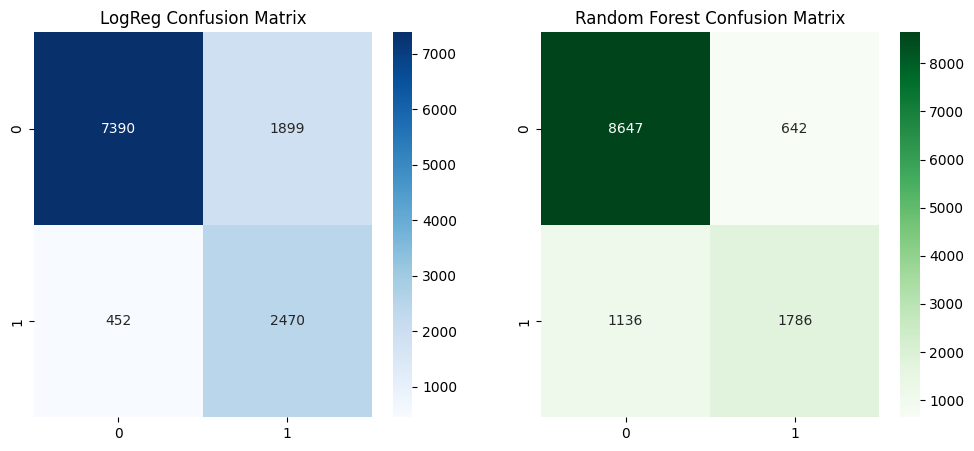

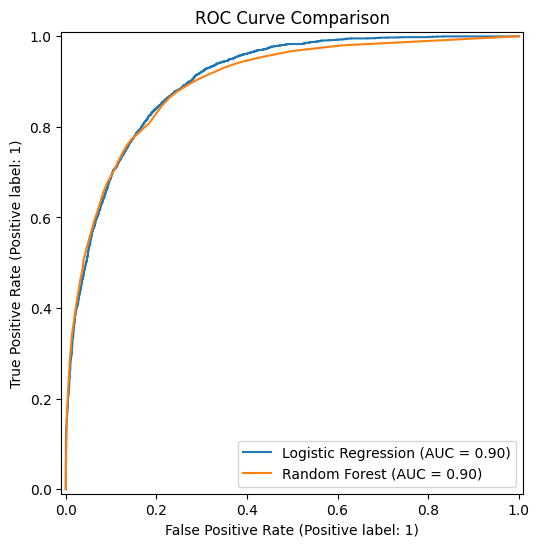

In [6]:
# Function to evaluate and print metrics
def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"--- {name} Evaluation ---")
    print(classification_report(y_true, y_pred))
    print(f"ROC-AUC Score: {roc_auc_score(y_true, y_prob):.4f}\n")

# Get probabilities for ROC
y_prob_log = log_reg_pipeline.predict_proba(X_test)[:, 1]
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

evaluate_model("Logistic Regression", y_test, y_pred_log, y_prob_log)
evaluate_model("Random Forest (Tuned)", y_test, y_pred_rf, y_prob_rf)

# Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("LogReg Confusion Matrix")
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("Random Forest Confusion Matrix")
plt.show()

# Plot ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(log_reg_pipeline, X_test, y_test, ax=ax, name="Logistic Regression")
RocCurveDisplay.from_estimator(best_rf, X_test, y_test, ax=ax, name="Random Forest")
plt.title("ROC Curve Comparison")
plt.show()

**Final Model Comparison Table**

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest (Tuned)"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

# Round results for readability
comparison_df = comparison_df.round(4)

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8075,0.5653,0.8453,0.6775,0.9049
1,Random Forest (Tuned),0.8544,0.7356,0.6112,0.6677,0.8977


**Ethical Check - Feature Importance**

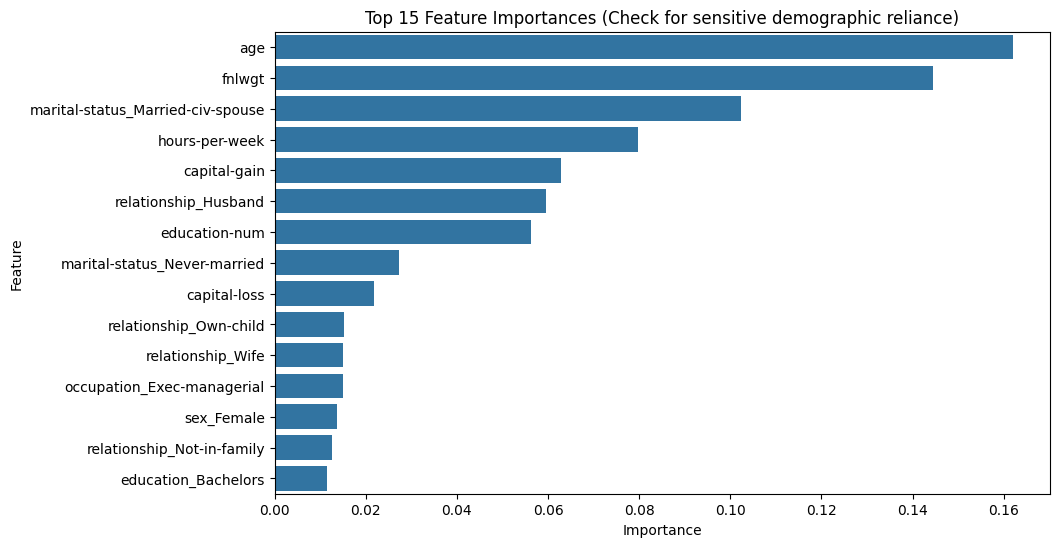

In [7]:
# Extract feature importance from the tuned Random Forest
rf_model = best_rf.named_steps['classifier']
categorical_encoder = best_rf.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']

# Reconstruct feature names
cat_features_names = categorical_encoder.get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numeric_features, cat_features_names])

# Create a DataFrame of feature importances
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot Top 15 Features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title('Top 15 Feature Importances (Check for sensitive demographic reliance)')
plt.show()